In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('smartcart_customers.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Data PreProcessing

### 1. Handle missing Value

In [7]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [11]:
df['Income']=df['Income'].fillna(df['Income'].median())

In [12]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

In [24]:
# AGE

df['Age']=2026-df['Year_Birth']

In [17]:
#Costumer joining Date

df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
refernce_day=df['Dt_Customer'].max()
df['Costumer_Tenure_Days']=(refernce_day-df['Dt_Customer']).dt.days

In [21]:
# spending
df['Total_Spending']=df['MntFishProducts']+df['MntFruits']+df['MntGoldProds']+df['MntMeatProducts']+df['MntSweetProducts']+df['MntWines']

In [22]:
# total childs

df['Total_Children']=df['Kidhome']+df['Teenhome']

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


### 3.Replace Values

In [31]:
# Education
# 2ncycle,basic=>undergraduate, graduation=>graduate  ,phd,master=>PostGraduate

df['Education']=df['Education'].replace({
    'Basic':'Undergraduate',
    '2n Cycle':'Undergraduate',
    'Graduation': 'Graduate',
    'Master':'Postgraduate',
    'PhD':'Postgraduate'
})


In [32]:
df['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [35]:
df.head() 

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [37]:
df['Marital_Status'].value_counts

df['Living_With']=df['Marital_Status'].replace({

    'Married':'Partner','Together':'Partner',
    'Single':'Alone','Divorced':'Alone',
    'Widow':'Alone','YOLO':'Alone','Absurd':'Alone'
})

In [39]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

### 4. drop columns


In [43]:
cols=['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts'
     ,'MntGoldProds']
df_clean=df.drop(columns=cols)
df_clean.shape

(2240, 15)

In [44]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


### 5.outliers

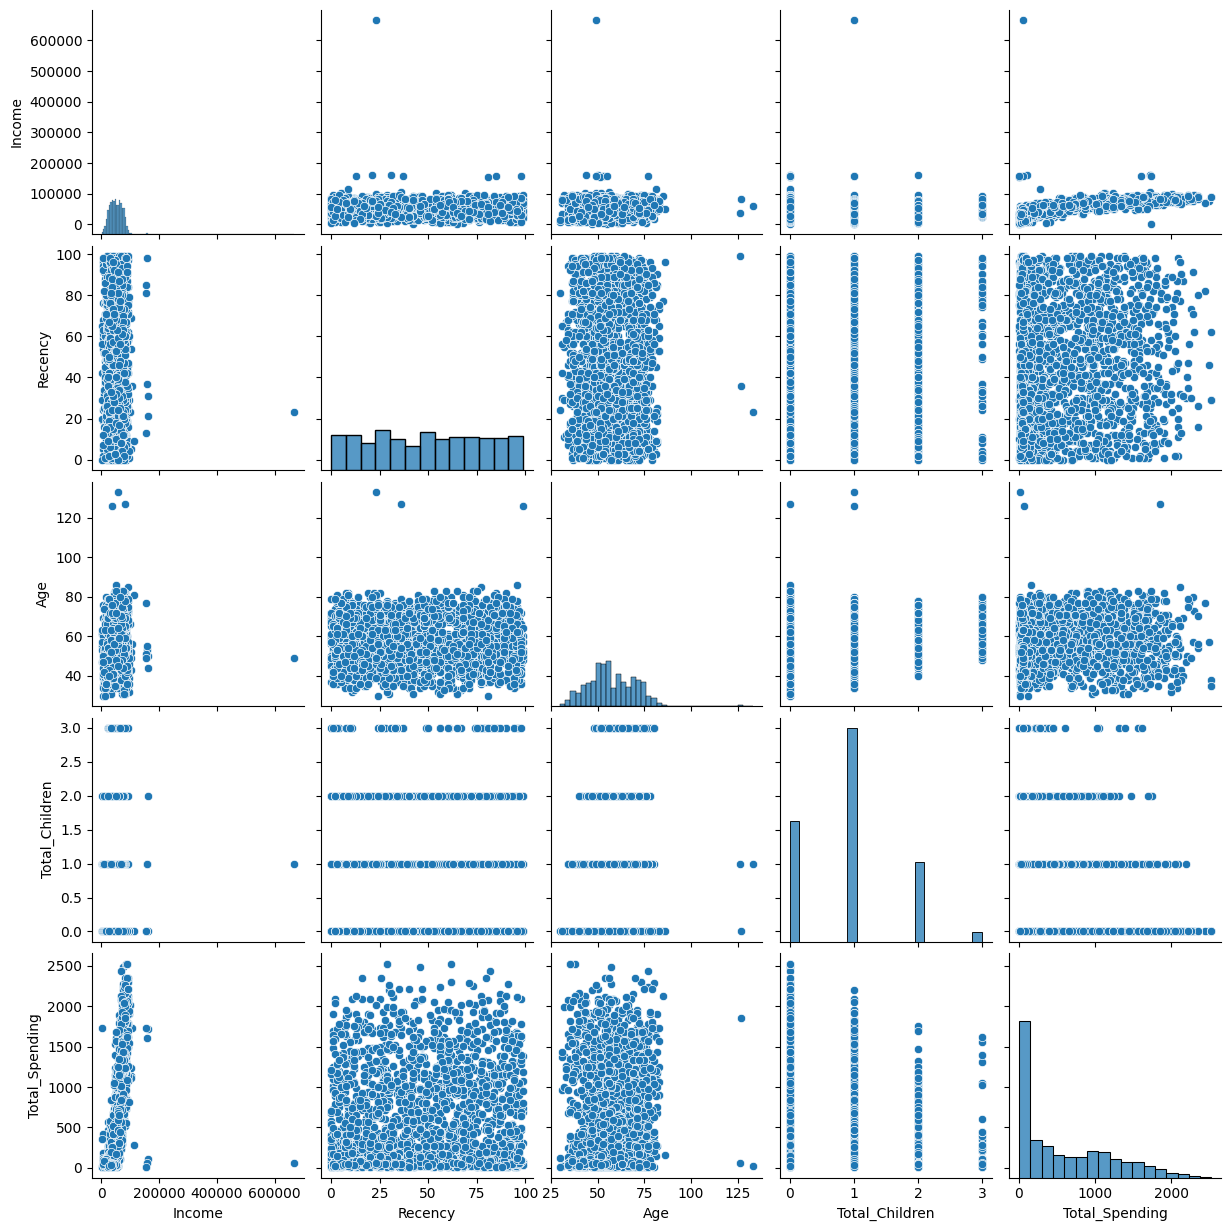

In [46]:
cols=['Income','Recency','Age','Total_Children','Total_Spending']
sns.pairplot(df_clean[cols])

In [47]:
# remove outliers

print('data size with outliers',len(df_clean))

df_clean=df_clean[(df_clean['Age']<90)]
df_clean=df_clean[(df_clean['Income']<600000)]

print('data size without outliers',len(df_clean))

data size with outliers 2240
data size without outliers 2236


<Axes: >

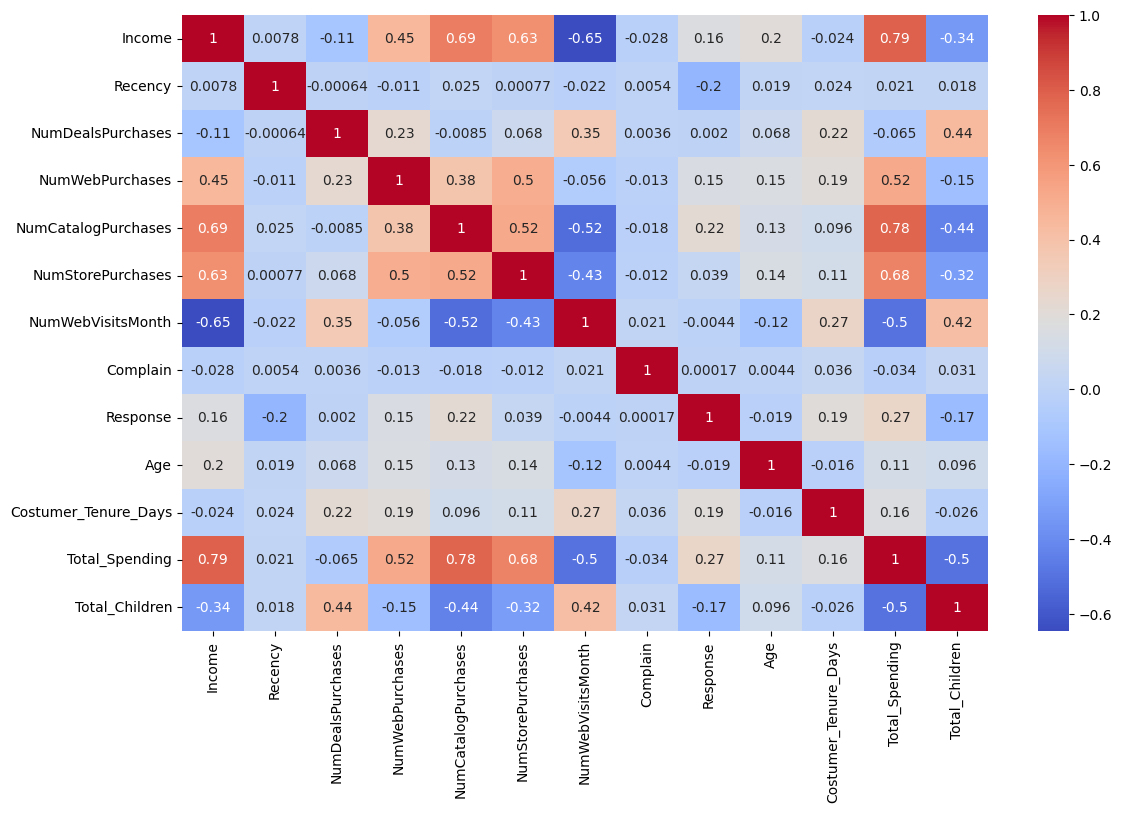

In [51]:
# Heatmap

corr=df_clean.corr(numeric_only=True)
plt.figure(figsize=(13,8))
sns.heatmap(
    data=corr,
    annot=True,
    cmap='coolwarm'
    
)

In [120]:
# the correlation shows

# high Income peoples ==> have high total_spend, high purchase catalog products, highly purchase store products , low website visits
# high total_spend ==> high catalog purchase , high store purchase , high incomes

In [53]:
df_clean.shape

(2236, 15)

### 6. Encoding

In [59]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

col=['Education','Living_With']

one_hot_encoder=OneHotEncoder()
enc_cols=one_hot_encoder.fit_transform(df_clean[col])
enc_cols.dtype

dtype('float64')

In [62]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=one_hot_encoder.get_feature_names_out(col),index=df_clean.index)
enc_df

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [64]:
df_encoded=pd.concat([df_clean.drop(columns=col),enc_df],axis=1)
df_encoded.shape

(2236, 18)

In [66]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


### 7. Scaling

In [68]:
from sklearn.preprocessing import StandardScaler

X=df_encoded
scalar=StandardScaler()
X_scaled=scalar.fit_transform(X)
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

### Visualize

In [69]:
X_scaled.shape
# it has 18 columsn we can't visualize 18 so we use pca to reduce dimenstionality

(2236, 18)

In [92]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)


Text(0.5, 0.92, 'PCA')

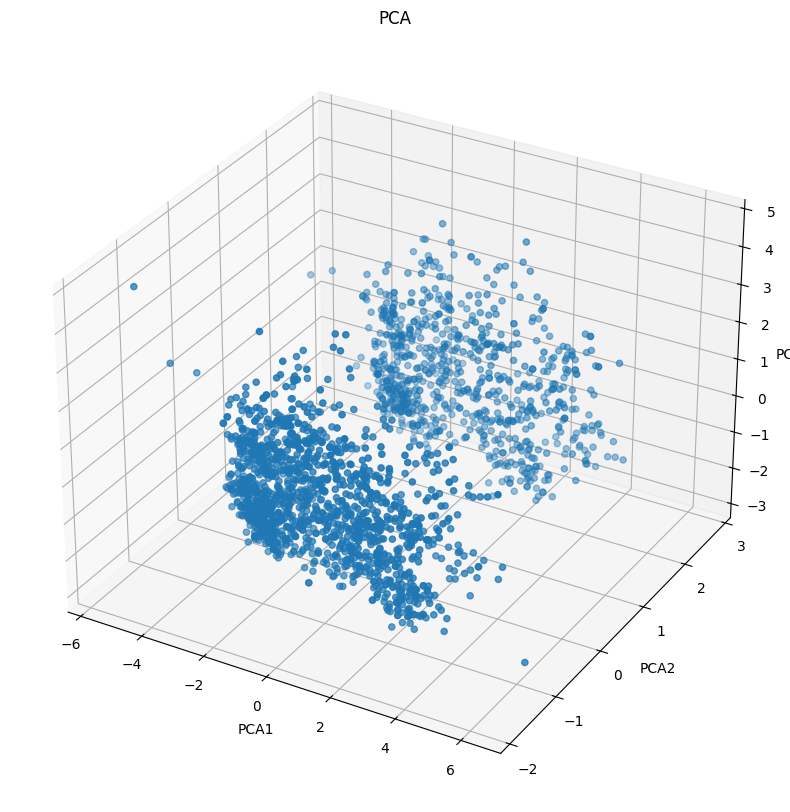

In [99]:
# plot
fig=plt.figure(figsize=(13,10))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('PCA')

In [100]:
pca.explained_variance_ratio_
# it shows variance of pca with 2 components and sum of both is approx 34 ,so model only retrived 34 % variance other are lost so we can increase dimension

array([0.23163158, 0.11385454, 0.10405815])

## Analyze The Value Of K

### 1. ELBOW METHOD

In [103]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
 
wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k=knee.elbow
print('the best k:',optimal_k)

the best k: 4


Text(0, 0.5, 'wcss')

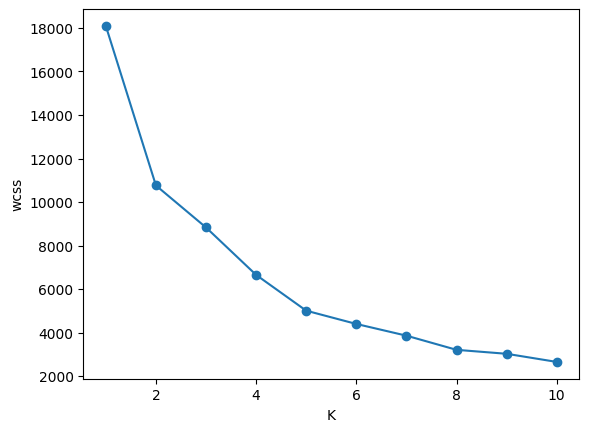

In [104]:
# plot of k 
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('K')
plt.ylabel('wcss')

### 2. Silhouette Score

Text(0, 0.5, 'Scores')

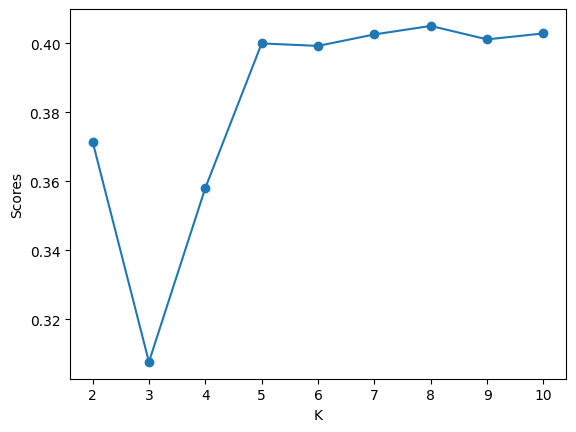

In [108]:
from sklearn.metrics import silhouette_score

scores=[]

for i in range(2,11):
    kmeanss=KMeans(n_clusters=i,random_state=42)
    labels=kmeanss.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker='o')
plt.xlabel('K')
plt.ylabel('Scores')


### Clustering

### 1. Kmeans clustering

In [109]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, 'PCA')

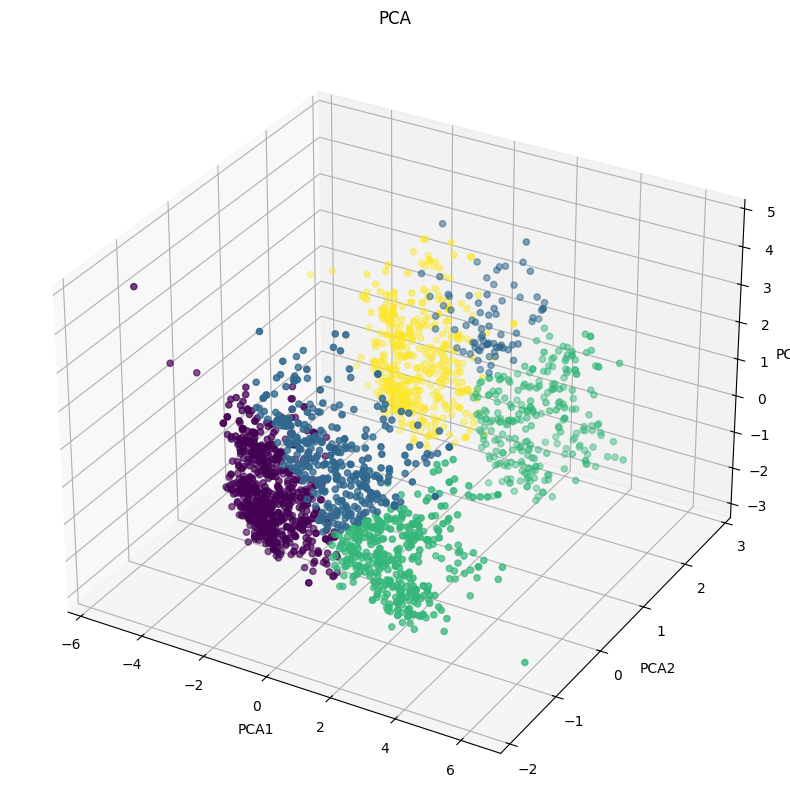

In [110]:
# plot

fig=plt.figure(figsize=(13,10))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('PCA')

### 2. Agglomerative Clustering

In [112]:
from sklearn.cluster import AgglomerativeClustering

agg=AgglomerativeClustering(n_clusters=4,linkage='ward')
label_agg=agg.fit_predict(X_pca)

Text(0.5, 0.92, 'PCA')

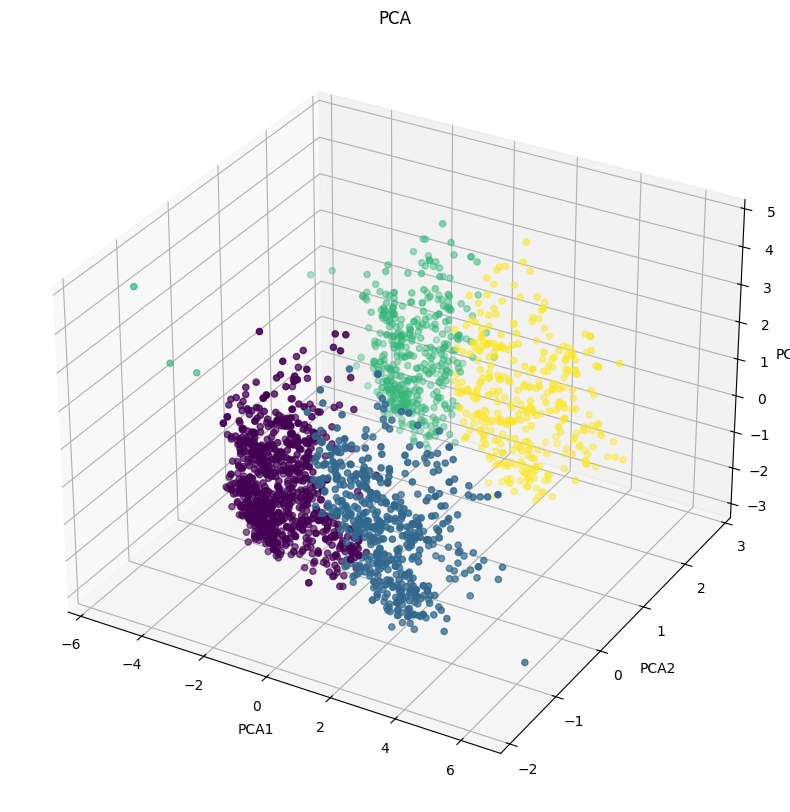

In [113]:
# plot
fig=plt.figure(figsize=(13,10))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label_agg)
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('PCA')

In [114]:
# Agglomerative gives best clustering

### Characterization of Clusters

In [126]:
X['cluster']=label_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Costumer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

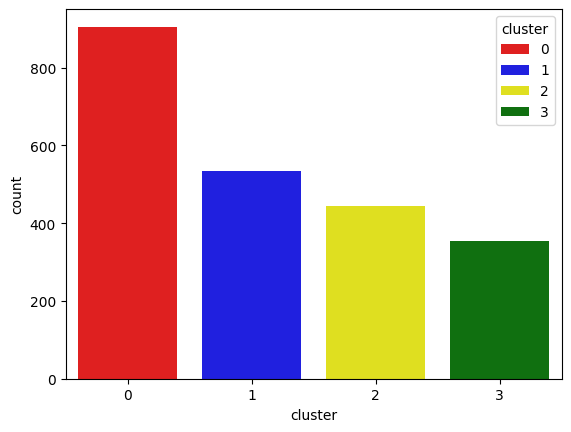

In [127]:
# to see how many count each cluster holds
pal=['red','blue','yellow','green']
sns.countplot(x=X['cluster'],palette=pal,hue=X['cluster'])

Text(0.5, 1.0, 'TOTAL_SPENDING AND INCOME PLOTS')

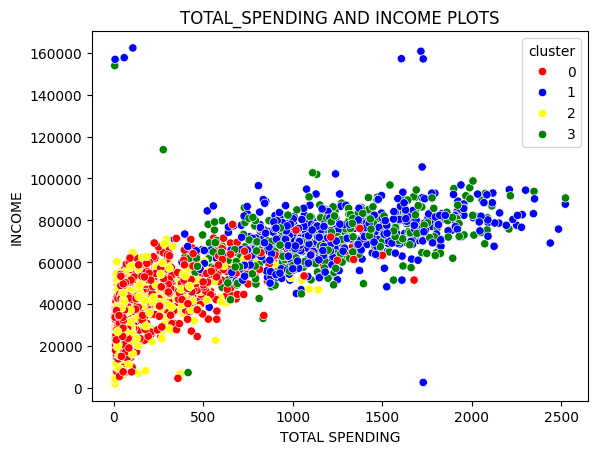

In [128]:
# income vs total_spending patterns with clusters

sns.scatterplot(x=X['Total_Spending'],y=X['Income'],hue=X['cluster'],palette=pal)
plt.xlabel('TOTAL SPENDING')
plt.ylabel('INCOME')
plt.title('TOTAL_SPENDING AND INCOME PLOTS')

In [125]:
# this chart shows that
#   red cluster ==> low/moderate income with low/moderate spending
#   yellow cluster ==> low income with low spending
#   green cluster ==> moderate/high income with high spending 
#   blue cluster ==> high income with high spending


### Cluster Summary

In [134]:
summary=X.groupby('cluster').mean()
print(summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Costumer_Tenure_Days  Total_Spending  \
cluster         